ML – MIDTERM EXAM (100 Marks)

This notebook is your **single submission file** for the Midterm.

- **Total marks:** 100  
  - Section A: 40 marks  
  - Section B: 60 marks  
- Answer **all questions** in this notebook.  
- Do **not** create a separate PDF.  
- Use clear headings, code, and explanations.

- Run all cells before submitting so all outputs are visible.
- Set the Colab file's shareable link to ‘Anyone with the link’ and ‘View’ access, then submit it in the Phitron Assignment module's Assignment submission section.

In [71]:
# Common imports for Section B (run once)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score, roc_curve, auc, roc_auc_score

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import RobustScaler
from sklearn.tree import DecisionTreeClassifier, plot_tree

plt.rcParams['figure.figsize'] = (6, 4)
plt.rcParams['axes.grid'] = True

---

## SECTION A – Short Application Questions (40 Marks)

Write your answers in the provided **answer cells** in this notebook. Use text, formulas, and short reasoning.

Marks for each question are clearly mentioned.

---

### Q1. Descriptive Statistics and Distributions (15 marks)

A dataset of monthly customer spending (in dollars) is:

`[30, 35, 32, 34, 33, 500, 31, 34, 32, 33]`

1. Compute the **median** and **IQR**. Show your working clearly.  
2. Use the **IQR rule** to check if 500 is an outlier. Show your steps and the fences.  
3. Explain in 3 to 5 sentences why **median + IQR** may be better than **mean + standard deviation** for this dataset.

Write your full answer in the cell below.


#### Q1 Answer (Student)

1. Median: 33.0, IQR: 2.0
2. Outliers: [500]
3. There the mean is 79.4, which does not represent the general value(30-35), on the other hand the median remains 33. Median  IQR are very resist to outliers, and provies more accurate summary than mean and standard deviation. That's why Median + IQR is better than Mean + Std Deviation

In [72]:
# Optional helper code for Q1 (not required)
data_q1 = [30, 35, 32, 34, 33, 500, 31, 34, 32, 33]
#Median
median = np.median(data_q1)
print(f"Median: {median}")

#Quartiles and IQR
q1 = np.percentile(data_q1, 25)
q3 = np.percentile(data_q1, 75)
iqr = q3 - q1
print(f"IQR: {iqr}")

#Check for outliers
lower_fence = q1 - 1.5 * iqr
upper_fence = q3 + 1.5 * iqr
outliers = [x for x in data_q1 if x < lower_fence or x > upper_fence]
print(f"Outliers: {outliers}")

#Mean and Standard Deviation
mean = np.mean(data_q1)
std = np.std(data_q1)
print(f"Mean: {mean}")
print(f"Standard Deviation: {std}")

Median: 33.0
IQR: 2.0
Outliers: [500]
Mean: 79.4
Standard Deviation: 140.2071324861899


### Q2. Bayes and Probability in ML (10 marks)

A disease affects **1 percent** of people.  
A test has:  
- Sensitivity: **90 percent**  
- Specificity: **92 percent**  

A random person tests positive.

1. Compute the **positive predictive value (PPV)** using Bayes theorem. Show all steps with probabilities.  
2. If prevalence rises to **20 percent**, explain in 3 to 4 sentences whether PPV increases or decreases and why. You may refer to the Bayes formula in words.

Write your full answer in the cell below.


#### Q2 Answer (Student)
1.

Prevalence: 0.01 (1%)

Sensitivity : 0.90 (90%)

Specificity : 0.92 (92%)

False Positive Rate = 1 - Specificity = 1 - 0.92 = 0.08

So, Total Probability of a Positive Test =  [0.90 X 0.01] + [0.08 X (1 - 0.01)] =  0.0882

Bayes' Theorem = (Sensitivity X Prevalence)/Total Probability
= 0.102 = 10.2%

2.
Bayes' theorem shows that PPV depends heavily on the prevalence. When the disease is rare 1%, most positive results are actually false. When the prevalence increases to 20%, the "true positive" portion of the equation becomes much larger relative to the false positives, shifting the probability of actually being sick given a positive test much higher.


### Q3. ML Pipeline Thinking (15 marks)

Columns in a new dataset:

- `age` (numeric)  
- `region` (categorical with 7 levels)  
- `daily_clicks` (numeric)  
- `premium_user` (0 or 1 target)

1. Identify the **type of ML task**. (1 or 2 lines)  
2. List **four preprocessing steps** that would be reasonable for this dataset. (bullet points are fine)  
3. In one short paragraph (6 to 8 sentences), describe the **end to end ML pipeline** you would follow for this problem, from raw data to model evaluation.

Write your full answer in the cell below.


#### Q3 Answer (Student)

1. Type of ML Task: This is a Binary Classification task because the target variable premium_user has two classes (0 or 1).

2. Four Preprocessing Steps:
   1. Missing Value Imputation
   2. Encoding: One-Hot Encoding to the region column to convert the 7 categorical levels into numeric.
   3. Feature Scaling: Z-score or Min-Max Scaling
   4. Train-Test Split: 80% train, 20% test

3. First, I would load the raw data and perform EDA to understand distributions, check for class imbalance, and identify outliers. Next, I would preprocess the data by imputing missing values, one-hot encoding the region feature, and scaling the numeric features age and daily_clicks to ensure all inputs are on a similar scale. I would then split the processed data into training and testing sets to prevent data leakage. After splitting, I would select and train a classification model, using the training set. Finally, I would evaluate the model's performance on the test set using metrics like Precision, Recall, and F1-score, rather than just accuracy.

---

## SECTION B – Applied Coding Problems (60 Marks)

Answer **all three questions** in this section.

- Write clean, commented code.  
- After each main step, add a short markdown explanation of what you did and what you observe.  
- Make sure all plots are visible in the notebook.

Marks for each question are clearly mentioned.

---

### Q4. Applied EDA and Preprocessing (20 marks)

We work with the following dataset:

```python
import pandas as pd

df = pd.DataFrame({
    "age": [25, 30, None, 22, 45, 52, None],
    "region": ["north","south","north","east","west","west","south"],
    "purchases": [3, 10, 5, None, 20, 18, 9],
    "premium_user": [0,1,0,0,1,1,0]
})
```

**Tasks (20 marks total):**

1. **Compact EDA using pandas** (6 marks)  
   - Show missing value summary for each column.  
   - Show number of unique values per column.  
   - Show correlation among numeric columns.  
   - Plot:  
     - A histogram of `purchases`.  
     - A bar chart for `region` frequency.

2. **Preprocess the dataset using sklearn plus pandas** (9 marks)  
   - Impute `age` with **median**.  
   - Impute `purchases` with **mean**.  
   - One hot encode `region`.  
   - Scale all numeric columns using **RobustScaler**.

3. **Create one domain driven feature** (3 marks)  
   - Example ideas: `high_spender` based on `purchases`, or `age_group` bins, or an interaction like `age * purchases`.

4. Show the **final transformed dataframe** ready for model training. (2 marks)

Use short explanations in markdown to describe each main block of code.


In [73]:
# Q4 – Student Answer

# Step 1: Create the dataframe
df = pd.DataFrame({
    "age": [25, 30, None, 22, 45, 52, None],
    "region": ["north","south","north","east","west","west","south"],
    "purchases": [3, 10, 5, None, 20, 18, 9],
    "premium_user": [0,1,0,0,1,1,0]
})

df

,age,region,purchases,premium_user
0,25.0,north,3.0,0
1,30.0,south,10.0,1
2,NaN,north,5.0,0
3,22.0,east,NaN,0
4,45.0,west,20.0,1
5,52.0,west,18.0,1
6,NaN,south,9.0,0


Missing Values:
 age             2
region          0
purchases       1
premium_user    0
dtype: int64

Unique Values:
 age             5
region          4
purchases       6
premium_user    2
dtype: int64

Correlation:
                    age  purchases  premium_user
age           1.000000   0.923677      0.789534
purchases     0.923677   1.000000      0.825860
premium_user  0.789534   0.825860      1.000000


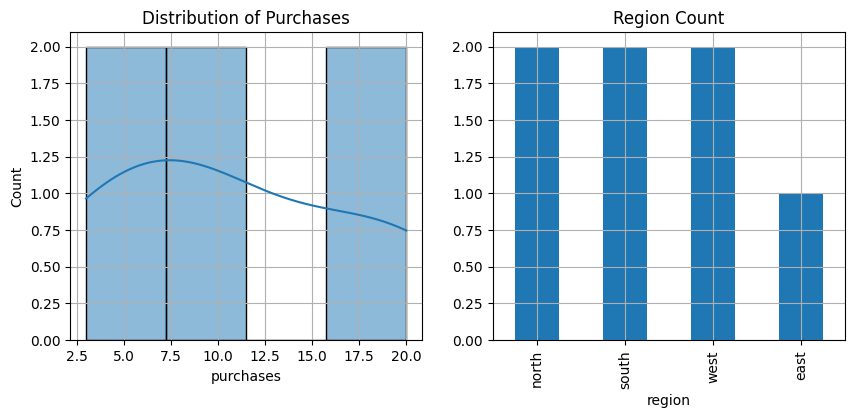

In [74]:
# Q4 – Student Answer
# 1. Compact EDA using pandas
import seaborn as sns
# Missing Values
print("Missing Values:\n", df.isnull().sum())

# Unique Values
print("\nUnique Values:\n", df.nunique())

# Correlation Matrix
print("\nCorrelation:\n", df.corr(numeric_only=True))

# Plots
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
sns.histplot(df['purchases'].dropna(), kde=True, ax=axes[0])
axes[0].set_title('Distribution of Purchases')
df['region'].value_counts().plot(kind='bar', ax=axes[1])
axes[1].set_title('Region Count')
plt.show()

Missing Values: age has 2 missing values, and purchases has 1.

Correlation: age and purchases are highly correlated (approx 0.92).

In [75]:
# Q4 – Student Answer
# 2: Preprocess the dataset using sklearn plus pandas

# Imputation
imputer_age = SimpleImputer(strategy='median')
df['age'] = imputer_age.fit_transform(df[['age']])


imputer_purchases = SimpleImputer(strategy='mean')
df['purchases'] = imputer_purchases.fit_transform(df[['purchases']])

# Scaling
scaler = RobustScaler()
df[['age', 'purchases']] = scaler.fit_transform(df[['age', 'purchases']])


# One-Hot Encoding
df = pd.get_dummies(df, columns=['region'], prefix='region', dtype=int)
df




,age,purchases,premium_user,region_east,region_north,region_south,region_west
0,-0.5,-0.943820,0,0,1,0,0
1,0.0,0.000000,1,0,0,1,0
2,0.0,-0.674157,0,0,1,0,0
3,-0.8,0.112360,0,1,0,0,0
4,1.5,1.348315,1,0,0,0,1
5,2.2,1.078652,1,0,0,0,1
6,0.0,-0.134831,0,0,0,1,0


In [76]:
# Q4 – Student Answer
# 3:  One domain driven feature
df['age_purchases_interaction'] = df['age'] * df['purchases']


In [77]:
# Q4 – Student Answer
# 4: final transformed dataframe
print(df.head(7))

   age  purchases  premium_user  region_east  region_north  region_south  \
0 -0.5  -0.943820             0            0             1             0   
1  0.0   0.000000             1            0             0             1   
2  0.0  -0.674157             0            0             1             0   
3 -0.8   0.112360             0            1             0             0   
4  1.5   1.348315             1            0             0             0   
5  2.2   1.078652             1            0             0             0   
6  0.0  -0.134831             0            0             0             1   

   region_west  age_purchases_interaction  
0            0                   0.471910  
1            0                   0.000000  
2            0                  -0.000000  
3            0                  -0.089888  
4            1                   2.022472  
5            1                   2.373034  
6            0                  -0.000000  


---

### Q5. Applied Regression and Residual Analysis (20 marks)

We use this dataset:

```python
import pandas as pd

df2 = pd.DataFrame({
    "area_sqft": [800, 1000, 1200, 1500, 1800, 2000],
    "bedrooms": [2,2,3,3,4,4],
    "price": [120, 150, 170, 210, 260, 300]
})
```

**Tasks (20 marks total):**

1. Create the dataframe `df2`. (1 mark)  
2. Split the data into **train and test** with 80 percent train and 20 percent test. (3 marks)  
3. Fit a **LinearRegression** model to predict `price` from `area_sqft` and `bedrooms`. (4 marks)  
4. Print model **intercept**, **coefficients**, and **predictions** on the test set. (4 marks)  
5. Compute the following metrics on the test set. (6 marks)  
   - Mean Absolute Error (MAE)  
   - Root Mean Squared Error (RMSE)  
   - R squared (R²)  
6. Plot a **residual plot** with `y_true − y_pred` on the vertical axis and `y_pred` on the horizontal axis. (2 marks)  
   - Add a short note explaining what you observe from the residuals.

Again, use short markdown explanations to describe each step.


In [78]:
# Q5 – Student Answer

# Step 1: Create the dataframe
df2 = pd.DataFrame({
    "area_sqft": [800, 1000, 1200, 1500, 1800, 2000],
    "bedrooms": [2,2,3,3,4,4],
    "price": [120, 150, 170, 210, 260, 300]
})

df2

# Step 2: Split the data
X = df2[['area_sqft', 'bedrooms']]
y = df2['price']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 3: Fit a LinearRegression model
model = LinearRegression()
model.fit(X_train, y_train)


LinearRegression()

*Q5 – Student Answer*
1. Created df2 with the provided data on area, bedrooms, and price.

2. Split the features "area_sqft", "bedrooms" and target "price" into training (80%) and testing (20%) sets.

3. Initialize and train a standard linear regression model on the training data.

In [79]:
# Q5 – Student Answer

# Step 4: Print model details and predictions
intercept = model.intercept_
coefficients = model.coef_
y_pred = model.predict(X_test)
print(f"Intercept: {intercept}")
print(f"Coefficients: {coefficients}")
print(f"Test Set Predictions: {y_pred}")
print(f"Test Set Actuals: {y_test.values}")

Intercept: -33.84615384615387
Coefficients: [0.15384615 5.38461538]
Test Set Predictions: [100.         130.76923077]
Test Set Actuals: [120 150]


*Q5 – Student Answer*

Extracted the learned parameters (intercept and coefficients) and make predictions on the unseen test set.

Intercept: -33.85

Coefficients: [0.15, 5.38] (Area coefficient, Bedroom coefficient)

Test Predictions: [100.0, 130.8]

In [80]:
# Q5 – Student Answer
# Step 5: Compute metrics
# Residuals = Actual - Predicted

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"MAE: {mae}")
print(f"RMSE: {rmse}")
print(f"R2: {r2}")

MAE: 19.615384615384613
RMSE: 19.61915499208746
R2: -0.7107166337935567


*Q5 – Student Answer*

Evaluate the model using Mean Absolute Error, Root Mean Squared Error, and R-squared.

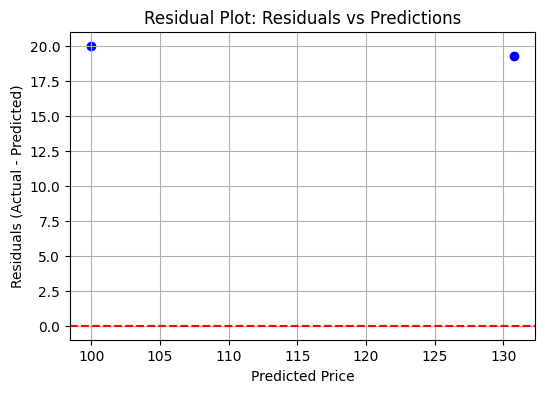

In [81]:
# Q5 – Student Answer

# Step 6: Residual Plot + Comment
residuals = y_test - y_pred

plt.figure(figsize=(6, 4))
plt.scatter(y_pred, residuals, color='blue')
plt.axhline(y=0, color='red', linestyle='--')  # Zero line for reference
plt.xlabel('Predicted Price')
plt.ylabel('Residuals (Actual - Predicted)')
plt.title('Residual Plot: Residuals vs Predictions')
plt.grid(True)
plt.show()

*Q5 – Student Answer*

The model consistently under-predicted the price for the homes in the test set. It predicted roughly 100 and 130, while the actual prices were 120 and 150. The current split shows a clear directional bias where the model undervalues the property.

---

### Q6. Applied Classification, Metrics, Trees and ROC (20 marks)

We start with:

```python
import numpy as np

y_true = np.array([1,0,1,0,1,0,1,0,1,0])
y_prob = np.array([0.9,0.1,0.85,0.2,0.7,0.4,0.6,0.3,0.95,0.05])
```

**Part 1: Threshold based classification and metrics (8 marks)**

1. With threshold **0.5**, convert probabilities to class predictions. Then compute:  
   - Confusion matrix  
   - Precision  
   - Recall  
   - F1 score

2. With threshold **0.3**, convert probabilities to class predictions again and recompute the same metrics.

3. In 3 to 4 sentences, explain how lowering the threshold from 0.5 to 0.3 changed precision and recall and why this happens.

**Part 2: ROC and AUC (6 marks)**

4. Plot the **ROC curve** using `y_true` and `y_prob`.  
5. Compute the **AUC** and print it with 3 decimal places.  
6. Add a one or two line comment on what a high or low AUC means in this context.

**Part 3: Decision Tree on a small dataset (6 marks)**

Create this dataset:

```python
df3 = pd.DataFrame({
    "hours": [1,2,3,4,5,1,2,3,4,5],
    "passed": [0,0,0,1,1,0,0,1,1,1]
})
```

7. Fit a `DecisionTreeClassifier(max_depth=2)` to predict `passed` from `hours`.  
8. Plot the tree using `plot_tree`.  
9. Write 2 to 3 lines explaining whether the tree looks like it might **overfit** or **generalize well**, given the dataset size and the model depth.


In [82]:
# Q6 – Student Answer

# Part 1: threshold based classification
y_true = np.array([1,0,1,0,1,0,1,0,1,0])
y_prob = np.array([0.9,0.1,0.85,0.2,0.7,0.4,0.6,0.3,0.95,0.05])

# 1. Threshold 0.5

y_pred_05 = (y_prob >= 0.5).astype(int)

# Metrics
cm_05 = confusion_matrix(y_true, y_pred_05)
prec_05 = precision_score(y_true, y_pred_05)
rec_05 = recall_score(y_true, y_pred_05)
f1_05 = f1_score(y_true, y_pred_05)

print("Threshold 0.5 Metrics:")
print("Confusion Matrix:\n", cm_05)
print(f"Precision: {prec_05}")
print(f"Recall: {rec_05}")
print(f"F1 Score: {f1_05}")

Threshold 0.5 Metrics:
Confusion Matrix:
 [[5 0]
 [0 5]]
Precision: 1.0
Recall: 1.0
F1 Score: 1.0


In [83]:
# Q6 – Student Answer

# Part 1: threshold based classification

# 2. Threshold 0.3
y_pred_03 = (y_prob >= 0.3).astype(int)

# Metrics
cm_03 = confusion_matrix(y_true, y_pred_03)
prec_03 = precision_score(y_true, y_pred_03)
rec_03 = recall_score(y_true, y_pred_03)
f1_03 = f1_score(y_true, y_pred_03)

print("\nThreshold 0.3 Metrics:")
print("Confusion Matrix:\n", cm_03)
print(f"Precision: {prec_03:.3f}")
print(f"Recall: {rec_03:.3f}")
print(f"F1 Score: {f1_03:.3f}")


Threshold 0.3 Metrics:
Confusion Matrix:
 [[3 2]
 [0 5]]
Precision: 0.714
Recall: 1.000
F1 Score: 0.833


*Q6 – Student Answer*

*Part 1: threshold based classification*

3. Lowering the threshold from 0.5 to 0.3 made the model more aggressive in predicting the positive class. As a result, Recall remained 1.0, but Precision decreased from 1.0 to 0.714. This happens because the lower threshold classified two negative instances (with probabilities 0.4 and 0.3) as positive, creating False Positives that lowered precision.

AUC: 1.000


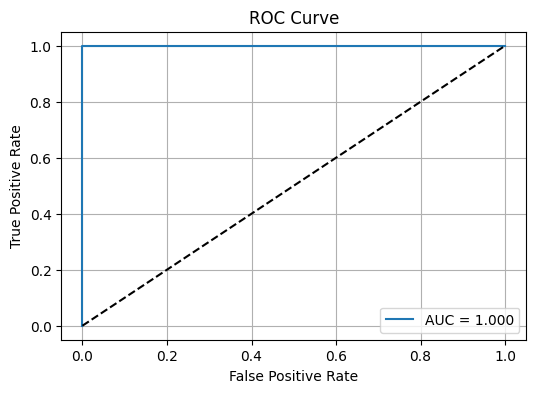

In [84]:
# Q6 – Student Answer

# Part 2: ROC and AUC

# 4 & 5: Plot ROC and Compute AUC

fpr, tpr, thresholds = roc_curve(y_true, y_prob)
auc = roc_auc_score(y_true, y_prob)

print(f"AUC: {auc:.3f}")

plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

*Q6 – Student Answer*

*Part 2: ROC and AUC*

*4 & 5: Plot ROC and Compute AUC*

An AUC of 1.0 indicates a perfect classifier that can perfectly separate positive and negative classes across all possible thresholds. A low AUC (near 0.5) would suggest the model is no better than random guessing.


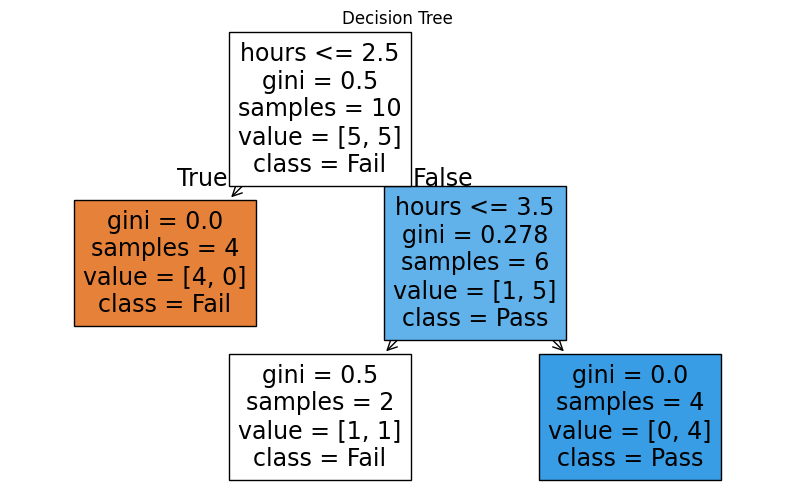

In [85]:
#Q6 – Student Answer

# Part 3: Decision Tree on a small dataset

# 7 & 8: Fit and Plot Tree

df3 = pd.DataFrame({
    "hours": [1,2,3,4,5,1,2,3,4,5],
    "passed": [0,0,0,1,1,0,0,1,1,1]
})

X = df3[['hours']]
y = df3['passed']

dt = DecisionTreeClassifier(max_depth=2, random_state=42)
dt.fit(X, y)

plt.figure(figsize=(10, 6))
plot_tree(dt, feature_names=['hours'], class_names=['Fail', 'Pass'], filled=True)
plt.title("Decision Tree")
plt.show()

*Q6 – Student Answer*

*Part 3: Decision Tree on a small dataset*

*9. Explanation of Overfitting vs. Generalization*

This tree likely generalizes well because it is simple (max_depth=2) and captures the clear relationship between study hours and passing (hours > 2.5 likely leads to a pass). With such a small dataset and low depth, it is essentially learning a simple threshold rule rather than memorizing noise (overfitting).